In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

In [2]:
ig = pd.read_csv(r"C:\Users\rober\Documents\Data Science\GitHub\DIY projects\Datasets\Instagram_Analytics.csv")

In [3]:
ig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   post_id           29999 non-null  object 
 1   upload_date       29999 non-null  object 
 2   media_type        29999 non-null  object 
 3   likes             29999 non-null  int64  
 4   comments          29999 non-null  int64  
 5   shares            29999 non-null  int64  
 6   saves             29999 non-null  int64  
 7   reach             29999 non-null  int64  
 8   impressions       29999 non-null  int64  
 9   caption_length    29999 non-null  int64  
 10  hashtags_count    29999 non-null  int64  
 11  followers_gained  29999 non-null  int64  
 12  traffic_source    29999 non-null  object 
 13  engagement_rate   29999 non-null  float64
 14  content_category  29999 non-null  object 
dtypes: float64(1), int64(9), object(5)
memory usage: 3.4+ MB


In [4]:
ig.describe().T

,count,mean,std,min,25%,50%,75%,max
likes,29999.0,9.991266e+04,57905.967401,7.00,49755.00,99580.00,150225.00,200000.00
comments,29999.0,5.017781e+03,2888.404881,0.00,2530.50,5042.00,7518.00,10000.00
shares,29999.0,2.502913e+03,1448.320395,0.00,1246.00,2498.00,3768.00,5000.00
saves,29999.0,7.490125e+03,4352.546949,0.00,3690.50,7483.00,11294.00,15000.00
reach,29999.0,9.965616e+05,577790.643192,165.00,493681.00,992181.00,1494798.00,1999865.00
impressions,29999.0,1.246669e+06,597092.365465,5107.00,746958.50,1241026.00,1749263.50,2497940.00
caption_length,29999.0,1.103111e+03,635.991308,0.00,555.00,1100.00,1656.00,2200.00
hashtags_count,29999.0,1.488743e+01,9.005811,0.00,7.00,15.00,23.00,30.00
followers_gained,29999.0,5.021528e+02,290.364038,0.00,251.00,501.00,755.00,1000.00
engagement_rate,29999.0,1.441928e+01,29.660210,0.12,5.18,9.19,15.67,3259.82


In [5]:
ig.head()

,post_id,upload_date,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
0,IG0000001,2024-11-30 09:25:22.954916,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology
1,IG0000002,2025-08-15 09:25:22.954916,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness
2,IG0000003,2025-09-11 09:25:22.954916,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty
3,IG0000004,2025-09-18 09:25:22.954916,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music
4,IG0000005,2025-03-21 09:25:22.954916,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,23.52,Technology


In [6]:
print("Unique Values per column:")
for col in ig.columns:
        print(f"{col}: {ig[col].nunique()}, {ig[col].dtype}")

Unique Values per column:
post_id: 29999, object
upload_date: 366, object
media_type: 4, object
likes: 27858, int64
comments: 9495, int64
shares: 4991, int64
saves: 12943, int64
reach: 29787, int64
impressions: 29781, int64
caption_length: 2201, int64
hashtags_count: 31, int64
followers_gained: 1001, int64
traffic_source: 6, object
engagement_rate: 4942, float64
content_category: 10, object


In [7]:
print ('Data Duplicates:', ig.duplicated().sum())
print ('-' *20)
print ('Missing Values per column:')
for col in ig.columns:
    print (f"{col}: {ig[col].isnull().sum()}")

Data Duplicates: 0
--------------------
Missing Values per column:
post_id: 0
upload_date: 0
media_type: 0
likes: 0
comments: 0
shares: 0
saves: 0
reach: 0
impressions: 0
caption_length: 0
hashtags_count: 0
followers_gained: 0
traffic_source: 0
engagement_rate: 0
content_category: 0


In [8]:
ig_no_id = ig.drop(['post_id'], axis =1)
ig_no_id.head()

,upload_date,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
0,2024-11-30 09:25:22.954916,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology
1,2025-08-15 09:25:22.954916,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness
2,2025-09-11 09:25:22.954916,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty
3,2025-09-18 09:25:22.954916,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music
4,2025-03-21 09:25:22.954916,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,23.52,Technology


In [9]:
ig_object = ig_no_id.select_dtypes(include=['object'])
ig_object.head()

,upload_date,media_type,traffic_source,content_category
0,2024-11-30 09:25:22.954916,Reel,Home Feed,Technology
1,2025-08-15 09:25:22.954916,Photo,Hashtags,Fitness
2,2025-09-11 09:25:22.954916,Reel,Reels Feed,Beauty
3,2025-09-18 09:25:22.954916,Reel,External,Music
4,2025-03-21 09:25:22.954916,Video,Profile,Technology


In [10]:
ig_number = ig_no_id.select_dtypes(include=['int64', 'float64'])
ig_number.head()

,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,engagement_rate
0,31627,7559,4530,6393,615036,1007750,1340,3,899,4.97
1,63206,3490,1680,6809,1237071,1345900,1351,20,805,5.59
2,94373,3727,1761,8367,1127470,1305369,242,24,758,8.29
3,172053,7222,2875,9290,764030,897874,446,11,402,21.32
4,99646,2703,4444,9746,7004,495406,1905,8,155,23.52


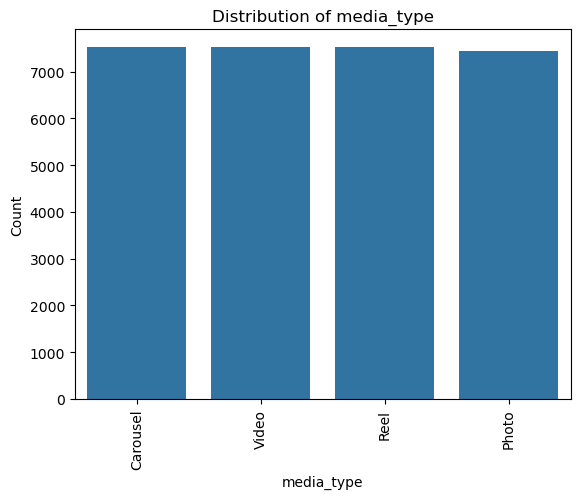

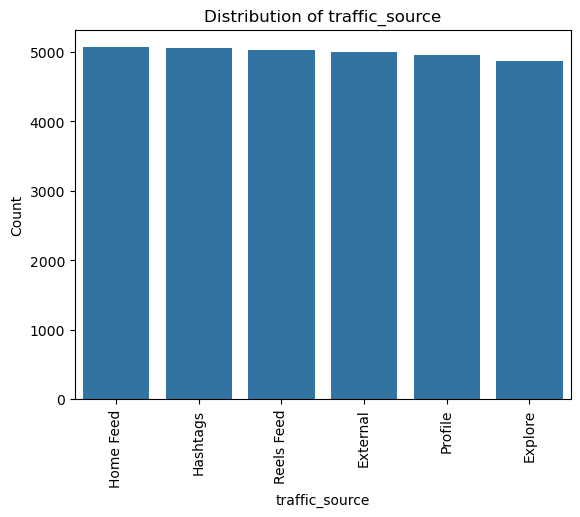

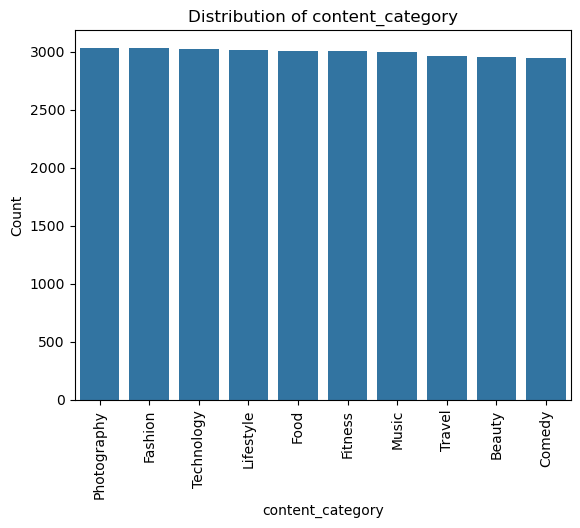

In [11]:
for col in ig_object.columns:
    if col == 'upload_date':
        continue
    sns.barplot(x=ig_object[col].value_counts().index, y = ig_object[col].value_counts().values)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.show()

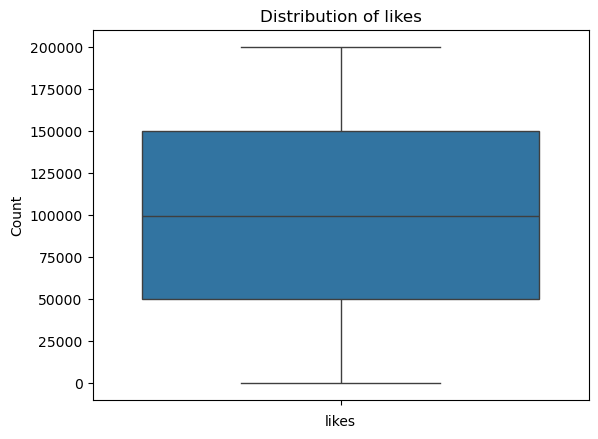

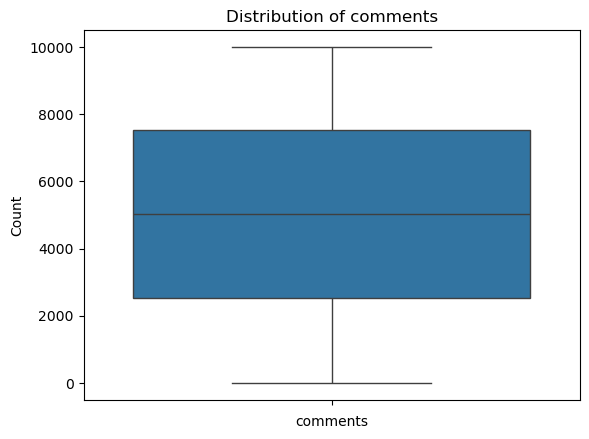

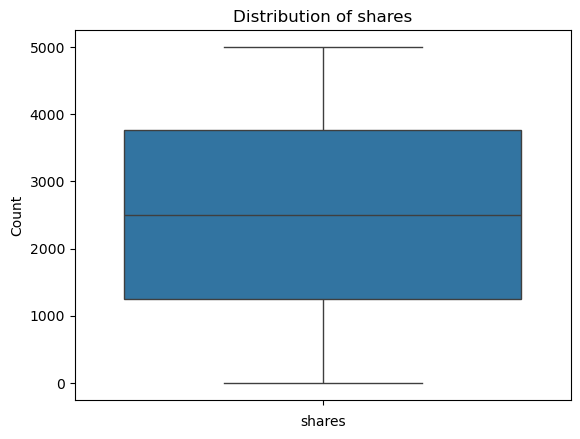

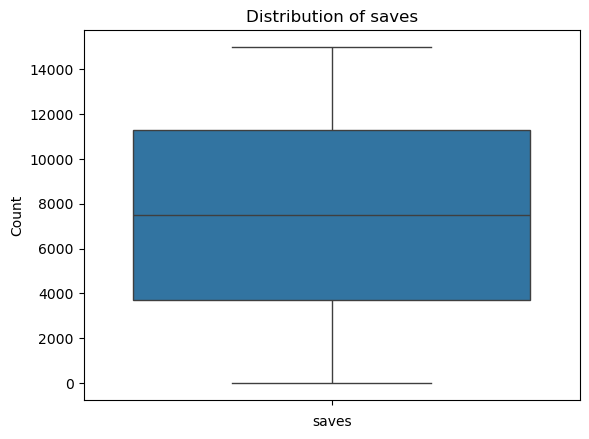

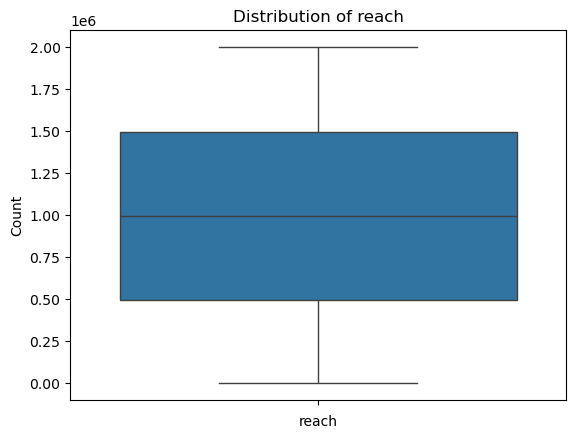

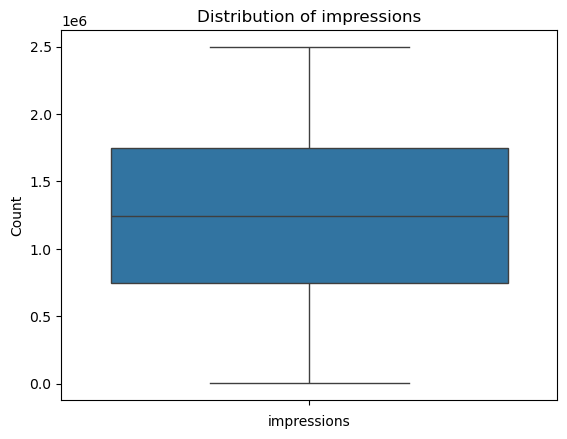

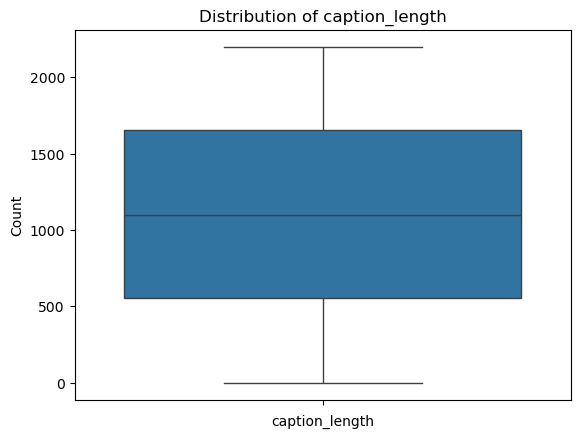

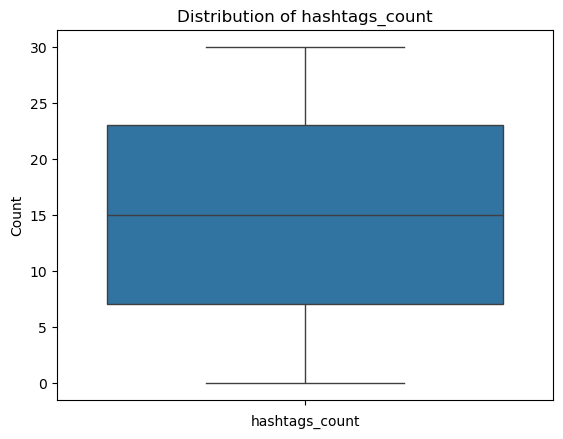

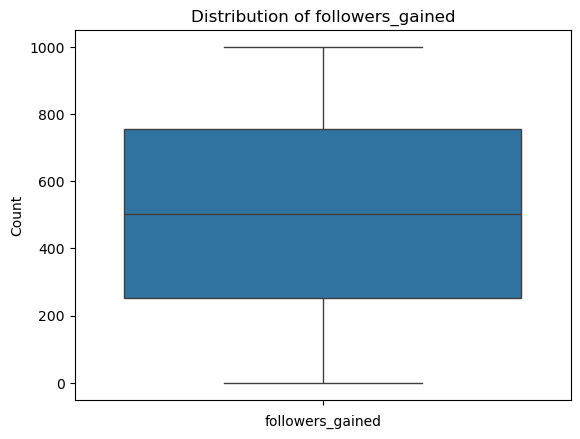

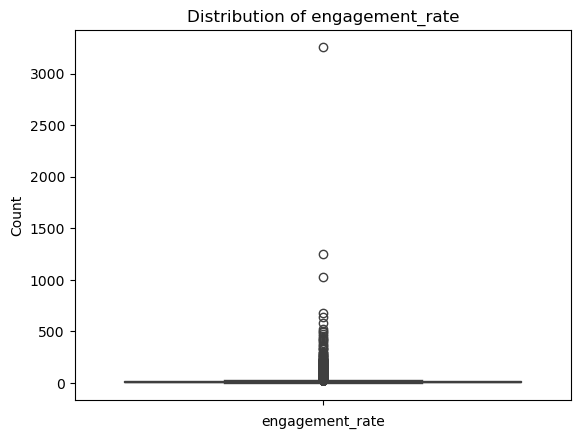

In [12]:
for col in ig_number.columns:
    sns.boxplot(ig_number[col].values)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.show()

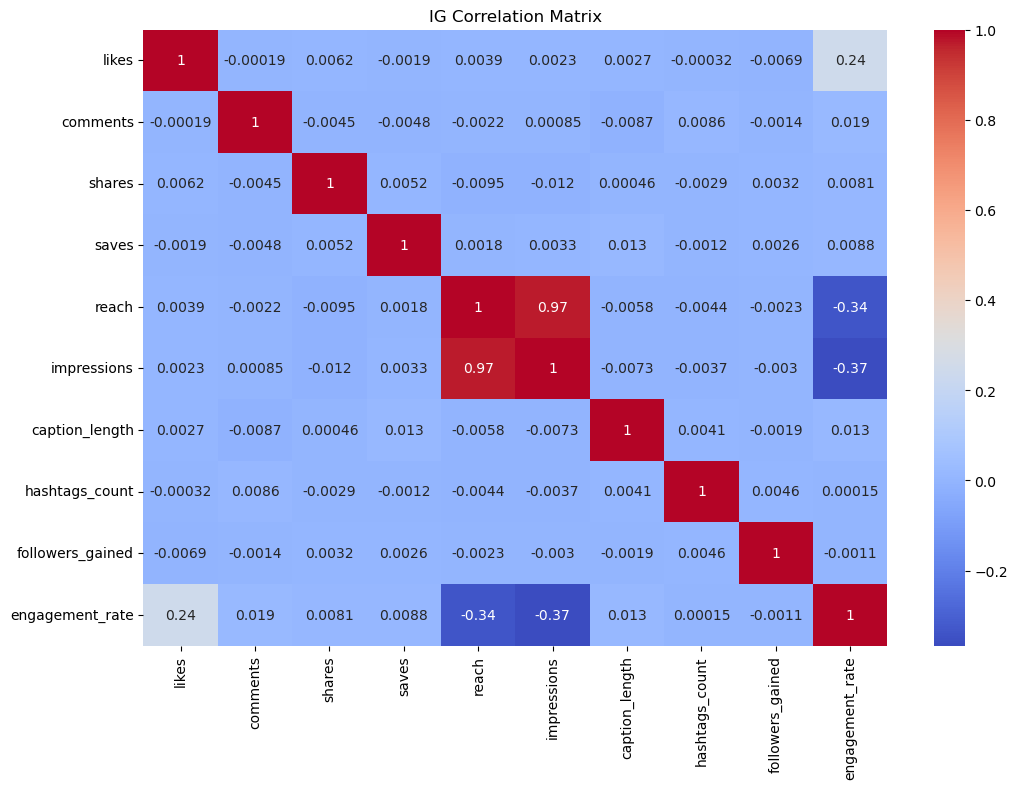

In [13]:
ig_number_corr = ig_number.corr()
plt.figure(figsize=(12,8))
sns.heatmap(ig_number_corr, annot=True, cmap='coolwarm')
plt.title('IG Correlation Matrix')
plt.show()

In [14]:
ig['engagement_rate'].describe()

count    29999.000000
mean        14.419276
std         29.660210
min          0.120000
25%          5.180000
50%          9.190000
75%         15.670000
max       3259.820000
Name: engagement_rate, dtype: float64

In [15]:
max_engagement = ig.loc[ig['engagement_rate'] > 15.67]
print("Posts with highest engagement rate:")
print(max_engagement[['post_id', 'upload_date', 'engagement_rate','media_type', 'traffic_source','content_category']])

Posts with highest engagement rate:
         post_id                 upload_date  engagement_rate media_type  \
3      IG0000004  2025-09-18 09:25:22.954916            21.32       Reel   
4      IG0000005  2025-03-21 09:25:22.954916            23.52      Video   
6      IG0000007  2025-09-21 09:25:22.954916            30.43   Carousel   
10     IG0000011  2025-04-09 09:25:22.954916            17.25      Video   
16     IG0000017  2025-07-11 09:25:22.954916            22.18      Photo   
...          ...                         ...              ...        ...   
29981  IG0029982  2025-10-28 09:25:22.954916            23.96       Reel   
29985  IG0029986  2024-11-24 09:25:22.954916            18.20      Video   
29988  IG0029989  2025-08-27 09:25:22.954916            18.58      Photo   
29989  IG0029990  2025-02-24 09:25:22.954916            19.34   Carousel   
29993  IG0029994  2025-02-10 09:25:22.954916            25.77   Carousel   

      traffic_source content_category  
3          

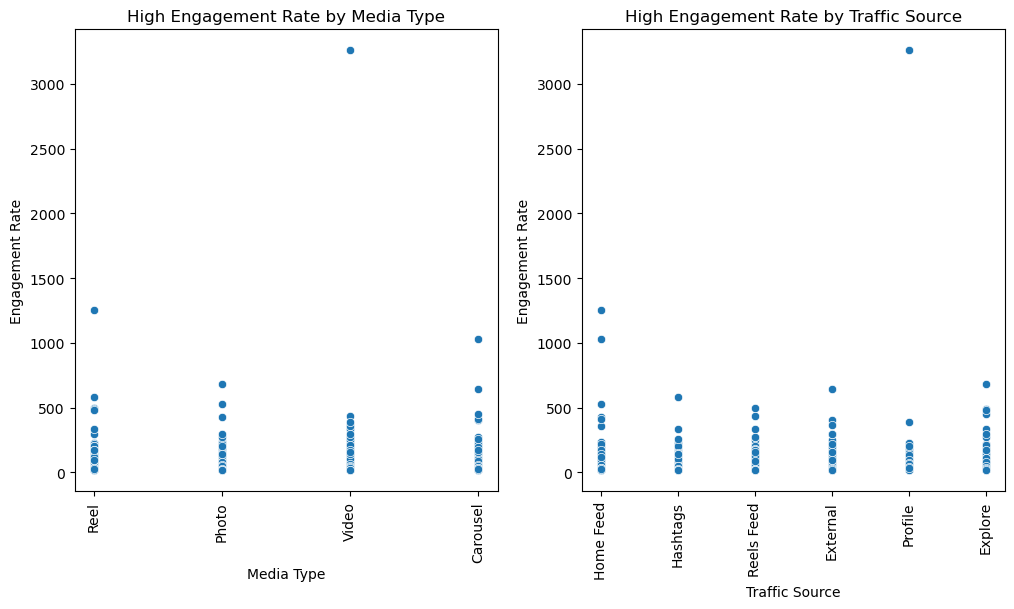

In [16]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.scatterplot(y = max_engagement['engagement_rate'], x = ig['media_type'])
plt.title('High Engagement Rate by Media Type')
plt.xticks(rotation=90)
plt.xlabel('Media Type')
plt.ylabel('Engagement Rate')

plt.subplot(1,2,2)
sns.scatterplot(y = max_engagement['engagement_rate'], x = ig['traffic_source'])
plt.title('High Engagement Rate by Traffic Source')
plt.xticks(rotation=90)
plt.xlabel('Traffic Source')
plt.ylabel('Engagement Rate')

plt.show()

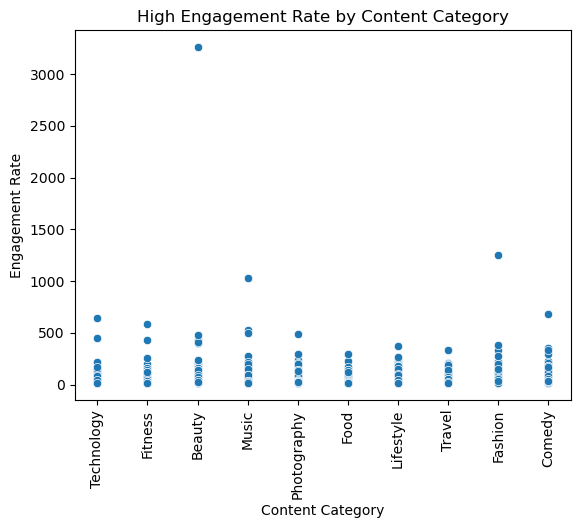

In [17]:
sns.scatterplot(y = max_engagement['engagement_rate'], x = ig['content_category'])
plt.title('High Engagement Rate by Content Category')
plt.xticks(rotation=90)
plt.xlabel('Content Category')
plt.ylabel('Engagement Rate')
plt.show()
